# Luxury Housing Analytics – Bangalore

End-to-end data pipeline for cleaning, transforming, and enriching luxury housing data for analytics and Power BI / dashboarding.

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import psycopg2
from sqlalchemy import create_engine

## 2. Data Loading and Initial Exploration

In [4]:
raw_data_path = 'C:\\Users\\USER\\Downloads\\Luxury_Housing_Bangalore.csv'
df = pd.read_csv(raw_data_path)
print('Data loaded successfully!')
df.head()

Data loaded successfully!


,Property_ID,Micro_Market,Project_Name,Developer_Name,Unit_Size_Sqft,Configuration,Ticket_Price_Cr,Transaction_Type,Buyer_Type,Purchase_Quarter,Connectivity_Score,Amenity_Score,Possession_Status,Sales_Channel,NRI_Buyer,Locality_Infra_Score,Avg_Traffic_Time_Min,Buyer_Comments
0,PROP000001,Sarjapur Road,Project_0,RMZ,4025.0,4bhk,12.750846039118798,Primary,NRI,2025-03-31,7.990091,5.462863,Launch,Broker,yes,9.212491,18,Loved the amenities!
1,PROP000002,Indiranagar,Project_1,Puravankara,5760.0,3Bhk,16.292151871065954,Primary,Other,2024-06-30,4.839024,NaN,Under construction,NRI Desk,no,7.723898,106,NaN
2,PROP000003,Bannerghatta Road,Project_2,Tata Housing,7707.0,4bhk,10.517724412961911,Primary,HNI,2023-12-31,8.131315,8.669227,Ready to move,Direct,yes,6.985493,113,Agent was not responsive.
3,PROP000004,bellary road,Project_3,Embassy,6192.0,3BHK,9.396367494232896,Primary,HNI,2024-03-31,7.501657,5.720246,Ready to move,Online,yes,6.100929,106,Excellent location!
4,PROP000005,Koramangala,Project_4,SNN Raj,7147.0,4Bhk,15.345392444511946,Secondary,HNI,2024-12-31,4.525216,8.609649,Under construction,Broker,no,5.312510,18,Too far from my office.


In [5]:
print('Columns Summary:')
print(df.describe(include=[np.number]))

print('\nData Types:')
print(df.dtypes)

print('\nDataset Info:')
print(df.info())

Columns Summary:
       Unit_Size_Sqft  Connectivity_Score  Amenity_Score  \
count    90954.000000       101000.000000   90910.000000   
mean      5972.274765            6.992619       7.503663   
std       1783.397836            1.731757       1.440758   
min         -1.000000            4.000031       5.000224   
25%       4477.250000            5.494526       6.260329   
50%       5990.000000            6.985805       7.499123   
75%       7497.000000            8.490000       8.752207   
max       8999.000000            9.999970       9.999865   

       Locality_Infra_Score  Avg_Traffic_Time_Min  
count         101000.000000         101000.000000  
mean               7.498426             67.182921  
std                1.443128             30.271611  
min                5.000013             15.000000  
25%                6.247954             41.000000  
50%                7.495614             67.000000  
75%                8.749824             93.000000  
max                9.99995

## 3. Remove Duplicates

In [6]:
print('Duplicate Rows...')
duplicates = df.duplicated().sum()
print(f'Total duplicates: {duplicates}')

print('Removing duplicates...')
initial_rows = len(df)
df = df.drop_duplicates(subset='Property_ID')
removed = initial_rows - len(df)
print(f'Removed {removed} duplicate rows based on Property_ID')
print(f'Duplicate Rows after cleaning: {df.duplicated(subset="Property_ID").sum()}')

Duplicate Rows...
Total duplicates: 1000
Removing duplicates...
Removed 1000 duplicate rows based on Property_ID
Duplicate Rows after cleaning: 0


## 4. Handling Missing Values – Amenity_Score

In [7]:
print('Handling Amenity_Score nulls...')

if 'Amenity_Score' in df.columns:
    missing_amenity = df['Amenity_Score'].isnull().sum()
    print(f'Missing Values BEFORE: {missing_amenity}')

    if missing_amenity > 0:
        median_amenity = df['Amenity_Score'].median()
        df['Amenity_Score'] = df['Amenity_Score'].fillna(median_amenity)
        print(f'Filled {missing_amenity} nulls with median: {median_amenity}')
    else:
        print('No missing values in Amenity_Score')

    print(f'Missing Values AFTER: {df["Amenity_Score"].isnull().sum()}')

Handling Amenity_Score nulls...
Missing Values BEFORE: 10000
Filled 10000 nulls with median: 7.49976649202713
Missing Values AFTER: 0


## 5. Cleaning Unit_Size_Sqft

In [8]:
print('Handling Unit_Size_Sqft column...')

if 'Unit_Size_Sqft' in df.columns:
    print(f'Missing Unit BEFORE: {df["Unit_Size_Sqft"].isnull().sum()}')

    # Treat negative values as invalid
    negative_unit = (df['Unit_Size_Sqft'] < 0).sum()
    if negative_unit > 0:
        df.loc[df['Unit_Size_Sqft'] < 0, 'Unit_Size_Sqft'] = np.nan

    # Fill missing / invalid values with median grouped by Configuration
    df['Unit_Size_Sqft'] = df.groupby('Configuration')['Unit_Size_Sqft'].transform(
        lambda x: x.fillna(x.median())
    )

    print(f'Missing Unit AFTER: {df["Unit_Size_Sqft"].isnull().sum()}')

Handling Unit_Size_Sqft column...
Missing Unit BEFORE: 9957
Missing Unit AFTER: 0


## 6. Cleaning Ticket_Price_Cr

In [9]:
print('Cleaning Ticket_Price_Cr column...')

if 'Ticket_Price_Cr' in df.columns:
    print(f'Missing values BEFORE: {df["Ticket_Price_Cr"].isnull().sum()}')

    # Strip non-numeric characters (₹, commas, text)
    df['Ticket_Price_Cr'] = df['Ticket_Price_Cr'].astype(str).str.replace('[^0-9.-]', '', regex=True)

    # Convert to numeric
    df['Ticket_Price_Cr'] = pd.to_numeric(df['Ticket_Price_Cr'], errors='coerce')
    print('Converted Ticket_Price_Cr to numeric')

    # Replace negative values with NaN
    negative_price = (df['Ticket_Price_Cr'] < 0).sum()
    print(f'Negative values found: {negative_price}')
    if negative_price > 0:
        df.loc[df['Ticket_Price_Cr'] < 0, 'Ticket_Price_Cr'] = np.nan
        print(f'Replaced {negative_price} negative values with NaN')

    print(f'Negative values AFTER: {(df["Ticket_Price_Cr"] < 0).sum()}')

    # Fill missing values using Micro_Market + Configuration median
    missing_values = df['Ticket_Price_Cr'].isnull().sum()
    print(f'Missing values to fill: {missing_values}')
    if missing_values > 0:
        df['Ticket_Price_Cr'] = df.groupby(['Micro_Market', 'Configuration'])['Ticket_Price_Cr'].transform(
            lambda x: x.fillna(x.median())
        )

    print(f'Missing values AFTER: {df["Ticket_Price_Cr"].isnull().sum()}')

Cleaning Ticket_Price_Cr column...
Missing values BEFORE: 9913
Converted Ticket_Price_Cr to numeric
Negative values found: 5
Replaced 5 negative values with NaN
Negative values AFTER: 0
Missing values to fill: 9918
Missing values AFTER: 0


## 7. Cleaning Buyer_Comments

In [10]:
# Replace missing comments with a neutral placeholder
df['Buyer_Comments'] = df['Buyer_Comments'].astype(str)
df['Buyer_Comments'] = df['Buyer_Comments'].replace('nan', 'No Comments from Buyer')

print('Unique Buyer_Comments values:')
print(df['Buyer_Comments'].unique())

Unique Buyer_Comments values:
['Loved the amenities!' 'No Comments from Buyer'
 'Agent was not responsive.' 'Excellent location!'
 'Too far from my office.' 'Underpriced for location.'
 'Will buy after possession.' 'Great value for money.'
 'Connectivity is poor.' 'Great view from 15th floor.']


## 8. Feature Engineering – Price_per_Sqft

In [11]:
print('Creating Price_per_Sqft...')
df['Price_per_Sqft'] = (df['Ticket_Price_Cr'] * 10000000) / df['Unit_Size_Sqft']
df['Price_per_Sqft'] = df['Price_per_Sqft'].round(2)
print('Price_per_Sqft created')

df['Price_per_Sqft'].describe()

Creating Price_per_Sqft...
Price_per_Sqft created


count    100000.000000
mean      22916.170898
std       15431.368652
min         995.620000
25%       15625.935000
50%       20035.390000
75%       26535.305000
max      324359.390000
Name: Price_per_Sqft, dtype: float64

In [12]:
# Remove extreme outliers in Price_per_Sqft
df = df[(df['Price_per_Sqft'] >= 2000) & (df['Price_per_Sqft'] <= 80000)]


In [13]:
df['Price_per_Sqft'].describe()


count    99072.000000
mean     21787.659712
std       8750.010407
min       2023.340000
25%      15588.265000
50%      19962.255000
75%      26290.800000
max      79990.860000
Name: Price_per_Sqft, dtype: float64

## 9. Feature Engineering – Quarter_Number

In [14]:
print('Creating Quarter_Number...')
df['Purchase_Quarter'] = pd.to_datetime(df['Purchase_Quarter'])
df['Quarter_Number'] = df['Purchase_Quarter'].dt.quarter
print('Quarter_Number created')

Creating Quarter_Number...
Quarter_Number created


In [15]:
df['Quarter_Number'].isnull().sum()
df['Quarter_Number'].unique()
df[['Purchase_Quarter','Quarter_Number']].head(10)



,Purchase_Quarter,Quarter_Number
0,2025-03-31,1
1,2024-06-30,2
2,2023-12-31,4
3,2024-03-31,1
4,2024-12-31,4
5,2023-09-30,3
6,2025-03-31,1
7,2025-03-31,1
8,2024-03-31,1
9,2023-09-30,3


## 10. Feature Engineering – Booking_Flag & Overall Property Score

In [16]:
print('Creating Booking_Flag and Overall_Property_Score...')

positive_keywords = ['buy', 'excellent', 'good', 'loved', 'great', 'nice', 'amazing']
negative_keywords = ['far', 'poor', 'not', 'no', 'expensive', 'responsive']

df['positive_intent'] = df['Buyer_Comments'].fillna('').str.lower().str.contains(
    '|'.join(positive_keywords), regex=True, na=False
)
df['negative_intent'] = df['Buyer_Comments'].fillna('').str.lower().str.contains(
    '|'.join(negative_keywords), regex=True, na=False
)

df['Booking_Flag'] = 0
df.loc[df['positive_intent'] == True, 'Booking_Flag'] = 1
df.loc[
    (df['Transaction_Type'].str.lower() == 'primary') &
    (df['negative_intent'] == False),
    'Booking_Flag'
] = 1

df['Overall_Property_Score'] = (
    df['Connectivity_Score'] * 0.3 +
    df['Amenity_Score'] * 0.3 +
    df['Locality_Infra_Score'] * 0.4
).round(2)

df.loc[
    (df['Overall_Property_Score'] > 8) &
    (df['Possession_Status'].str.lower() == 'ready to move') &
    (df['Booking_Flag'] == 0),
    'Booking_Flag'
] = 1

# Clean up temporary columns
df.drop(['positive_intent', 'negative_intent'], axis=1, inplace=True)

print('Feature engineering complete.')

Creating Booking_Flag and Overall_Property_Score...
Feature engineering complete.


In [17]:
df['Booking_Flag'].value_counts()
df['Overall_Property_Score'].describe()
df[['Connectivity_Score','Amenity_Score','Locality_Infra_Score','Overall_Property_Score','Booking_Flag']].head(10)


,Connectivity_Score,Amenity_Score,Locality_Infra_Score,Overall_Property_Score,Booking_Flag
0,7.990091,5.462863,9.212491,7.72,1
1,4.839024,7.499766,7.723898,6.79,1
2,8.131315,8.669227,6.985493,7.83,0
3,7.501657,5.720246,6.100929,6.41,1
4,4.525216,8.609649,5.312510,6.07,0
5,7.936068,7.499766,5.154027,6.69,0
6,8.643117,8.355238,9.791550,9.02,0
7,6.781306,9.565013,9.054713,8.53,1
8,7.284164,5.580442,8.552046,7.28,1
9,9.964399,7.759907,8.395691,8.68,0


## Amenity Score

In [18]:
# Amenity Bucket based on Amenity Score
def amenity_bucket(score):
    if score < 6:
        return "Low"
    elif score < 8:
        return "Medium"
    else:
        return "High"

df['Amenity_Bucket'] = df['Amenity_Score'].apply(amenity_bucket)


## Comment sentiment

In [19]:
positive_words = ['loved', 'excellent', 'great', 'amazing']
negative_words = ['not', 'poor', 'far', 'responsive']

def get_sentiment(comment):
    text = comment.lower()
    
    if any(word in text for word in positive_words):
        return "Positive"
    elif any(word in text for word in negative_words):
        return "Negative"
    else:
        return "Neutral"

df['Comment_Sentiment'] = df['Buyer_Comments'].apply(get_sentiment)


## 11. Standardizing Columns & Data Types

In [20]:
print('Standardizing columns...')

df['Micro_Market'] = df['Micro_Market'].astype(str).str.strip().str.upper()
df['Developer_Name'] = df['Developer_Name'].astype(str).str.strip().str.upper()
df['Configuration'] = df['Configuration'].astype(str).str.strip().str.upper()
df['Transaction_Type'] = df['Transaction_Type'].astype(str).str.strip().str.title()
df['Buyer_Type'] = df['Buyer_Type'].astype(str).str.strip().str.title()
df['Possession_Status'] = df['Possession_Status'].astype(str).str.strip().str.title()
df['Sales_Channel'] = df['Sales_Channel'].astype(str).str.strip().str.title()
df['NRI_Buyer'] = df['NRI_Buyer'].astype(str).str.strip().str.title()
df['Buyer_Comments'] = df['Buyer_Comments'].astype(str).str.strip()

df['Purchase_Quarter'] = pd.to_datetime(df['Purchase_Quarter'], errors='coerce')

numeric_cols = ['Unit_Size_Sqft', 'Ticket_Price_Cr', 'Price_per_Sqft',
                'Connectivity_Score', 'Amenity_Score', 'Locality_Infra_Score',
                'Overall_Property_Score', 'Avg_Traffic_Time_Min']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Standardization complete.')

Standardizing columns...
Standardization complete.


In [21]:
df[['Micro_Market','Developer_Name','Configuration','Transaction_Type']].head(15)


,Micro_Market,Developer_Name,Configuration,Transaction_Type
0,SARJAPUR ROAD,RMZ,4BHK,Primary
1,INDIRANAGAR,PURAVANKARA,3BHK,Primary
2,BANNERGHATTA ROAD,TATA HOUSING,4BHK,Primary
3,BELLARY ROAD,EMBASSY,3BHK,Primary
4,KORAMANGALA,SNN RAJ,4BHK,Secondary
5,YELAHANKA,BRIGADE,4BHK,Secondary
6,BANNERGHATTA ROAD,PRESTIGE,5BHK+,Secondary
7,WHITEFIELD,TOTAL ENVIRONMENT,3BHK,Secondary
8,SARJAPUR ROAD,PRESTIGE,3BHK,Secondary
9,JP NAGAR,PURAVANKARA,4BHK,Primary


In [22]:
df['NRI_Buyer'].unique()


array(['Yes', 'No'], dtype=object)

In [23]:
df['Buyer_Type'].unique()


array(['Nri', 'Other', 'Hni', 'Cxo', 'Startup Founder'], dtype=object)

In [24]:
df['Purchase_Quarter'].dtype


dtype('<M8[ns]')

In [25]:
df[['Unit_Size_Sqft','Ticket_Price_Cr','Price_per_Sqft']].head()


,Unit_Size_Sqft,Ticket_Price_Cr,Price_per_Sqft
0,4025.0,12.750846,31679.12
1,5760.0,16.292152,28284.99
2,7707.0,10.517724,13646.98
3,6192.0,9.396367,15175.01
4,7147.0,15.345392,21471.10


## 12. Geocoding Micro_Market for Map Visualisation

In [54]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [55]:
# If geopy is not installed, uncomment the following line:
##pip install geopy

from geopy.geocoders import Nominatim
import time

unique_markets = df['Micro_Market'].unique()
geolocator = Nominatim(user_agent='geoapi_luxury_housing')

latitudes = []
longitudes = []

for market in unique_markets:
    location = geolocator.geocode(f'{market}, Bangalore, India')
    time.sleep(1)  # be gentle with the API

    if location:
        latitudes.append(location.latitude)
        longitudes.append(location.longitude)
    else:
        latitudes.append(None)
        longitudes.append(None)

geo_df = pd.DataFrame({
    'Micro_Market': unique_markets,
    'Latitude': latitudes,
    'Longitude': longitudes
})

df = df.merge(geo_df, on='Micro_Market', how='left')
df.columns

Index(['Property_ID', 'Micro_Market', 'Project_Name', 'Developer_Name',
       'Unit_Size_Sqft', 'Configuration', 'Ticket_Price_Cr',
       'Transaction_Type', 'Buyer_Type', 'Purchase_Quarter',
       'Connectivity_Score', 'Amenity_Score', 'Possession_Status',
       'Sales_Channel', 'NRI_Buyer', 'Locality_Infra_Score',
       'Avg_Traffic_Time_Min', 'Buyer_Comments', 'Price_per_Sqft',
       'Quarter_Number', 'Booking_Flag', 'Overall_Property_Score',
       'Amenity_Bucket', 'Comment_Sentiment', 'Latitude', 'Longitude'],
      dtype='object')

## 13. Save Cleaned Dataset

In [56]:
print('Saving the cleaned data...')

import os

cleaned_data_dir = "C:\\Users\\USER\\OneDrive\\Desktop\\"
os.makedirs(cleaned_data_dir, exist_ok=True)

cleaned_data_path = cleaned_data_dir + 'luxury_housing_cleaned.csv'
df.to_csv(cleaned_data_path, index=False)

print(f'Cleaned data saved to: {cleaned_data_path}')

Saving the cleaned data...
Cleaned data saved to: C:\Users\USER\OneDrive\Desktop\luxury_housing_cleaned.csv


## 14. Unique Micro_Markets with Coordinates

In [57]:
unique_markets_table = df[['Micro_Market', 'Latitude', 'Longitude']].drop_duplicates().reset_index(drop=True)
unique_markets_table

,Micro_Market,Latitude,Longitude
0,SARJAPUR ROAD,12.923993,77.639745
1,INDIRANAGAR,12.973291,77.640467
2,BANNERGHATTA ROAD,12.951742,77.603949
3,BELLARY ROAD,13.048762,77.592416
4,KORAMANGALA,12.935737,77.624081
5,YELAHANKA,13.100698,77.596345
6,WHITEFIELD,12.996400,77.761423
7,JP NAGAR,12.909694,77.586607
8,RAJAJINAGAR,13.000536,77.549700
9,JAYANAGAR,12.929273,77.582423


In [ ]:
df

,Property_ID,Micro_Market,Project_Name,Developer_Name,Unit_Size_Sqft,Configuration,Ticket_Price_Cr,Transaction_Type,Buyer_Type,Purchase_Quarter,...,Avg_Traffic_Time_Min,Buyer_Comments,Price_per_Sqft,Quarter_Number,Booking_Flag,Overall_Property_Score,Amenity_Bucket,Comment_Sentiment,Latitude,Longitude
0,PROP000001,SARJAPUR ROAD,Project_0,RMZ,4025.0,4BHK,12.750846,Primary,Nri,2025-03-31,...,18,Loved the amenities!,31679.12,1,1,7.72,Low,Positive,12.924563,77.638258
1,PROP000002,INDIRANAGAR,Project_1,PURAVANKARA,5760.0,3BHK,16.292152,Primary,Other,2024-06-30,...,106,No Comments from Buyer,28284.99,2,1,6.79,Medium,Neutral,12.973291,77.640467
2,PROP000003,BANNERGHATTA ROAD,Project_2,TATA HOUSING,7707.0,4BHK,10.517724,Primary,Hni,2023-12-31,...,113,Agent was not responsive.,13646.98,4,0,7.83,High,Negative,12.926288,77.600426
3,PROP000004,BELLARY ROAD,Project_3,EMBASSY,6192.0,3BHK,9.396367,Primary,Hni,2024-03-31,...,106,Excellent location!,15175.01,1,1,6.41,Low,Positive,13.032459,77.587898
4,PROP000005,KORAMANGALA,Project_4,SNN RAJ,7147.0,4BHK,15.345392,Secondary,Hni,2024-12-31,...,18,Too far from my office.,21471.10,4,0,6.07,High,Negative,12.935737,77.624081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99067,PROP099996,BELLARY ROAD,Project_495,L&T REALTY,5550.0,5BHK+,10.185193,Primary,Nri,2023-12-31,...,109,Underpriced for location.,18351.70,4,1,8.12,Medium,Neutral,13.032459,77.587898
99068,PROP099997,YELAHANKA,Project_496,L&T REALTY,3171.0,4BHK,12.272081,Secondary,Other,2023-12-31,...,20,Great view from 15th floor.,38700.98,4,1,6.14,Medium,Positive,13.100698,77.596345
99069,PROP099998,RAJAJINAGAR,Project_497,PRESTIGE,5599.0,4BHK,13.730179,Primary,Startup Founder,2023-09-30,...,63,No Comments from Buyer,24522.56,3,1,7.70,Medium,Neutral,13.000523,77.549617
99070,PROP099999,INDIRANAGAR,Project_498,SNN RAJ,7342.0,4BHK,10.363989,Primary,Nri,2024-09-30,...,89,No Comments from Buyer,14116.03,3,1,7.80,Medium,Neutral,12.973291,77.640467


In [58]:
df.head()
df.tail()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99072 entries, 0 to 99071
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Property_ID             99072 non-null  object        
 1   Micro_Market            99072 non-null  object        
 2   Project_Name            99072 non-null  object        
 3   Developer_Name          99072 non-null  object        
 4   Unit_Size_Sqft          99072 non-null  float64       
 5   Configuration           99072 non-null  object        
 6   Ticket_Price_Cr         99072 non-null  float64       
 7   Transaction_Type        99072 non-null  object        
 8   Buyer_Type              99072 non-null  object        
 9   Purchase_Quarter        99072 non-null  datetime64[ns]
 10  Connectivity_Score      99072 non-null  float64       
 11  Amenity_Score           99072 non-null  float64       
 12  Possession_Status       99072 non-null  object

In [65]:
#1. Load Cleaned Dataset
df = pd.read_csv("C:\\Users\\USER\\OneDrive\\Desktop\\luxury_housing_cleaned.csv")
print("Cleaned dataset loaded:", df.shape)


Cleaned dataset loaded: (99072, 26)


In [66]:
# 2. PostgreSQL Connection
# ============================
username = "postgres"
password = "Sarath"
host = "localhost"
port = "5432"
database = "luxury_db"

# Using SQLAlchemy engine for to_sql()
engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

print("PostgreSQL connection successful!")

PostgreSQL connection successful!


In [67]:
# 3. Upload Data into SQL Table
# ============================
df.to_sql(
    "luxury_housing_blr",
    engine,
    if_exists="append",   # append so table structure is not replaced
    index=False
)

print("Data successfully inserted into table: luxury_housing_blr")

Data successfully inserted into table: luxury_housing_blr


In [68]:
# 4. Validate Row Count
# ============================
conn = psycopg2.connect(
    host=host,
    database=database,
    port=port,
    user=username,
    password=password
)

cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM luxury_housing_blr;")
count = cur.fetchone()[0]
conn.close()

print("Total rows now in SQL table:", count)


Total rows now in SQL table: 99072


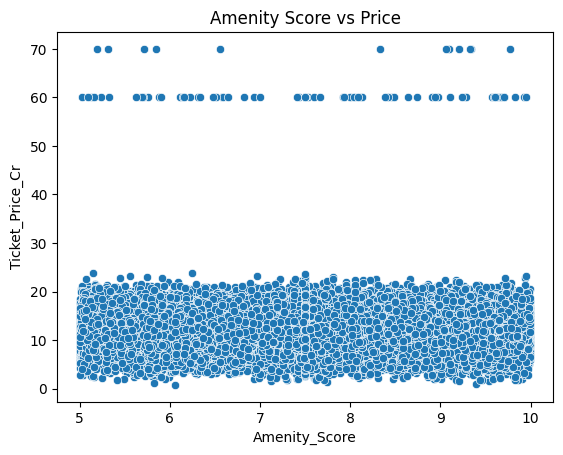

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x=df['Amenity_Score'], y=df['Ticket_Price_Cr'])
plt.title("Amenity Score vs Price")
plt.show()
